## **Download and Move Data**

In [1]:
# import os
# os.getcwd()

In [2]:
# import kagglehub
# path = kagglehub.dataset_download("nih-chest-xrays/data")

In [3]:
# print(path)

In [4]:
# import os
# os.listdir(path)

In [5]:
# dest_dir = "./dataset/images"
# os.makedirs(dest_dir, exist_ok=True)

In [6]:
# import shutil

# base_dir = "/home/jovyan/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3"

# for i in range(1, 11):
#     folder = f"{base_dir}/images_{i:03d}/images"
#     if os.path.exists(folder):
#         for img in os.listdir(folder):
#             src = os.path.join(folder, img)
#             dst = os.path.join(dest_dir, img)

#             shutil.move(src, dst)

## **Load Data**

In [7]:
import torch
print(torch.cuda.is_available())

True


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision.transforms import transforms
from tqdm import tqdm
from torchmetrics.classification import MultilabelAccuracy

In [9]:
# df = pd.read_csv("/root/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3/Data_Entry_2017.csv")
df = pd.read_csv("./Data_Entry_2017.csv")

In [10]:
import os

image_dir = "./dataset/images"

df = df[df["Image Index"].apply(
    lambda img: os.path.exists(os.path.join(image_dir, img))
)].reset_index(drop=True)


In [11]:
df.shape

(94999, 12)

In [12]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


## **EDA**

In [13]:
df["View Position"].unique()

array(['PA', 'AP'], dtype=object)

In [14]:
view_pos_counts = df["View Position"].value_counts()
view_pos_counts

View Position
PA    56844
AP    38155
Name: count, dtype: int64

In [15]:
import matplotlib.pyplot as plt

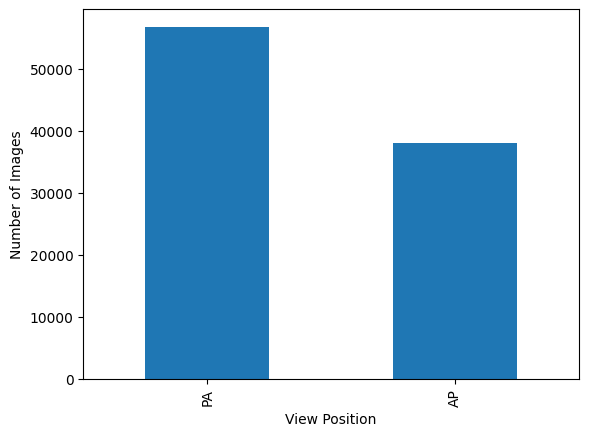

In [16]:
view_pos_counts.plot(kind="bar")

plt.xlabel("View Position")
plt.ylabel("Number of Images")

plt.show()

### **Making Multihotencoded Vector**

In [17]:
finding_labels_list = df["Finding Labels"].tolist()

In [18]:
len(finding_labels_list)

94999

In [19]:
finding_labels = set()

for label in finding_labels_list:
  splitted_labels = label.split("|")
  for disease in splitted_labels:
    finding_labels.add(disease)


In [20]:
finding_labels = list(finding_labels)

In [21]:
len(finding_labels)

15

In [22]:
finding_labels = sorted(finding_labels)

In [23]:
finding_labels.remove("No Finding")
finding_labels

['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Pneumothorax']

In [24]:
labels = {label:index for index,label in enumerate(finding_labels)}
labels

{'Atelectasis': 0,
 'Cardiomegaly': 1,
 'Consolidation': 2,
 'Edema': 3,
 'Effusion': 4,
 'Emphysema': 5,
 'Fibrosis': 6,
 'Hernia': 7,
 'Infiltration': 8,
 'Mass': 9,
 'Nodule': 10,
 'Pleural_Thickening': 11,
 'Pneumonia': 12,
 'Pneumothorax': 13}

In [25]:
def get_label(row_labels):
  row_labels_list = row_labels.split("|")
  vector = np.zeros(len(finding_labels))

  for label in row_labels_list:
    if label in finding_labels:
      if label == "No Finding":
        continue
      index = labels[label]
      vector[index] = 1

  return vector


In [26]:
df["Label"] = df["Finding Labels"].apply(lambda x : get_label(x))

In [27]:
df["Label"][3]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [28]:
df = df[["Image Index","Label"]]

In [29]:
df.head()

,Image Index,Label
0,00000001_000.png,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,00000001_001.png,"[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ..."
2,00000001_002.png,"[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
3,00000002_000.png,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,00000003_000.png,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."


In [30]:
df.shape

(94999, 2)

In [31]:
df_sample = df.sample(50000,random_state=42).reset_index(drop=True)
df_sample.head()

,Image Index,Label
0,00011211_006.png,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,00003863_009.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,00007471_000.png,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,00015031_011.png,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,00012772_004.png,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [32]:
df_sample.shape

(50000, 2)

In [33]:
train_df,test_df = train_test_split(df_sample,test_size=0.2,random_state=42)

In [34]:
train_df.shape

(40000, 2)

In [35]:
test_df.shape

(10000, 2)

In [36]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    #Convert the channels H W C to C H W and scales (0 255) to (0 1)
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [37]:
class ChestXRayDataset(Dataset):
  def __init__(self,df,image_dir,transform=None):
    self.df = df
    self.image_dir = image_dir
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, index):
    image_file_name = self.df.iloc[index]["Image Index"]
    label = self.df.iloc[index]["Label"]

    image_path = os.path.join(self.image_dir,image_file_name)

    #because densenet was trained on rgb images sooo..
    image = Image.open(image_path).convert("RGB")

    if self.transform:
      image = self.transform(image)

    label = torch.tensor(label,dtype=torch.float32)

    return image,label


In [38]:
image_file_name = df_sample["Image Index"][3]
print(f"File name : {image_file_name}")

image_path = f"./dataset/images/{image_file_name}"
print(f"Image path : {image_path}")

image = Image.open(image_path).convert("RGB")
image = train_transform(image)
print(f"Image shape : {image.shape}")

File name : 00015031_011.png
Image path : ./dataset/images/00015031_011.png
Image shape : torch.Size([3, 224, 224])


In [39]:
image

tensor([[[0.6784, 0.7059, 0.6980,  ..., 0.0980, 0.0980, 0.0824],
         [0.7137, 0.7412, 0.7333,  ..., 0.1020, 0.1020, 0.0863],
         [0.7137, 0.7412, 0.7333,  ..., 0.1020, 0.1020, 0.0863],
         ...,
         [0.8471, 0.8863, 0.8824,  ..., 0.4706, 0.6667, 0.6667],
         [0.8510, 0.8863, 0.8824,  ..., 0.4667, 0.6510, 0.6667],
         [0.8471, 0.8824, 0.8784,  ..., 0.4706, 0.6275, 0.6549]],

        [[0.6784, 0.7059, 0.6980,  ..., 0.0980, 0.0980, 0.0824],
         [0.7137, 0.7412, 0.7333,  ..., 0.1020, 0.1020, 0.0863],
         [0.7137, 0.7412, 0.7333,  ..., 0.1020, 0.1020, 0.0863],
         ...,
         [0.8471, 0.8863, 0.8824,  ..., 0.4706, 0.6667, 0.6667],
         [0.8510, 0.8863, 0.8824,  ..., 0.4667, 0.6510, 0.6667],
         [0.8471, 0.8824, 0.8784,  ..., 0.4706, 0.6275, 0.6549]],

        [[0.6784, 0.7059, 0.6980,  ..., 0.0980, 0.0980, 0.0824],
         [0.7137, 0.7412, 0.7333,  ..., 0.1020, 0.1020, 0.0863],
         [0.7137, 0.7412, 0.7333,  ..., 0.1020, 0.1020, 0.

In [40]:
image_dir = "./dataset/images"
train_dataset = ChestXRayDataset(df=train_df,image_dir=image_dir,transform=train_transform)
test_dataset = ChestXRayDataset(df=test_df,image_dir=image_dir,transform=test_transform)

In [41]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [42]:
model = models.densenet161(weights=True)

/opt/conda/envs/myenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet161_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet161_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [43]:
num_in_features = model.classifier.in_features
num_in_features

2208

In [44]:
model.classifier

Linear(in_features=2208, out_features=1000, bias=True)

In [45]:
model.classifier = nn.Linear(num_in_features, 14)

In [46]:
for param in model.features.parameters():
    param.requires_grad = False

In [47]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

classifier.weight
classifier.bias


In [48]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_labels = 14
metric = MultilabelAccuracy(num_labels,average="macro").to(device)

print("Training started.")

for epoch in range(5):
    #setting the model to training mode
    model.train()
    total_loss = 0
    metric.reset()

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        probs = torch.sigmoid(outputs)
        metric.update(probs,labels)
        
    epoch_acc = metric.compute()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)} Acc : {epoch_acc}")

Training started.


100% 1250/1250 [08:57<00:00,  2.33it/s]


Epoch 1, Loss: 0.1879973877310753 Acc : 0.9470750093460083


100% 1250/1250 [08:54<00:00,  2.34it/s]


Epoch 2, Loss: 0.17399040710926056 Acc : 0.9485321640968323


...

Epoch 3, Loss: 0.17070462867617608 Acc : 0.9485589265823364


100% 1250/1250 [08:50<00:00,  2.36it/s]


Epoch 4, Loss: 0.16890075526833534 Acc : 0.9485732316970825


100% 1250/1250 [08:54<00:00,  2.34it/s]

Epoch 5, Loss: 0.16759617009162903 Acc : 0.9485750198364258


In [50]:
model.eval()

test_loss = 0
metric.reset()

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        probs = torch.sigmoid(outputs)
        metric.update(probs,labels)
print(f"Test Loss : {test_loss / len(test_loader)} Test Acc : {metric.compute()}")

100% 313/313 [02:14<00:00,  2.32it/s]

Test Loss : 0.16701086208271904 Test Acc : 0.9490286111831665


In [51]:
Path = "./model_weights.pth"
torch.save(model.state_dict(),Path)

In [52]:
import os
from pathlib import Path

PATH = './model_weights.pth' 

# Using os.path.exists()
if os.path.exists(PATH):
    print(f"File found: {PATH}")
else:
    print(f"File not found: {PATH}")

# Alternatively, using pathlib
file_path = Path(PATH)
if file_path.is_file():
    print(f"File found: {file_path}")
else:
    print(f"File not found: {file_path}")


File found: ./model_weights.pth
File found: model_weights.pth


In [53]:
model.load_state_dict(torch.load("model.pth"))
print(f"Best Val Acc: {best_val_acc:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: 'model.pth'